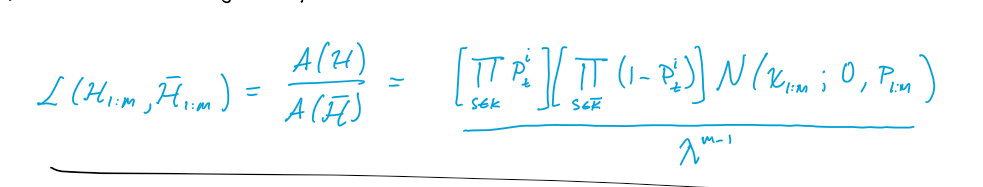

In [67]:
import numpy as np
from scipy.stats import multivariate_normal

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
true_states = np.random.uniform(-5, 5, 1000)

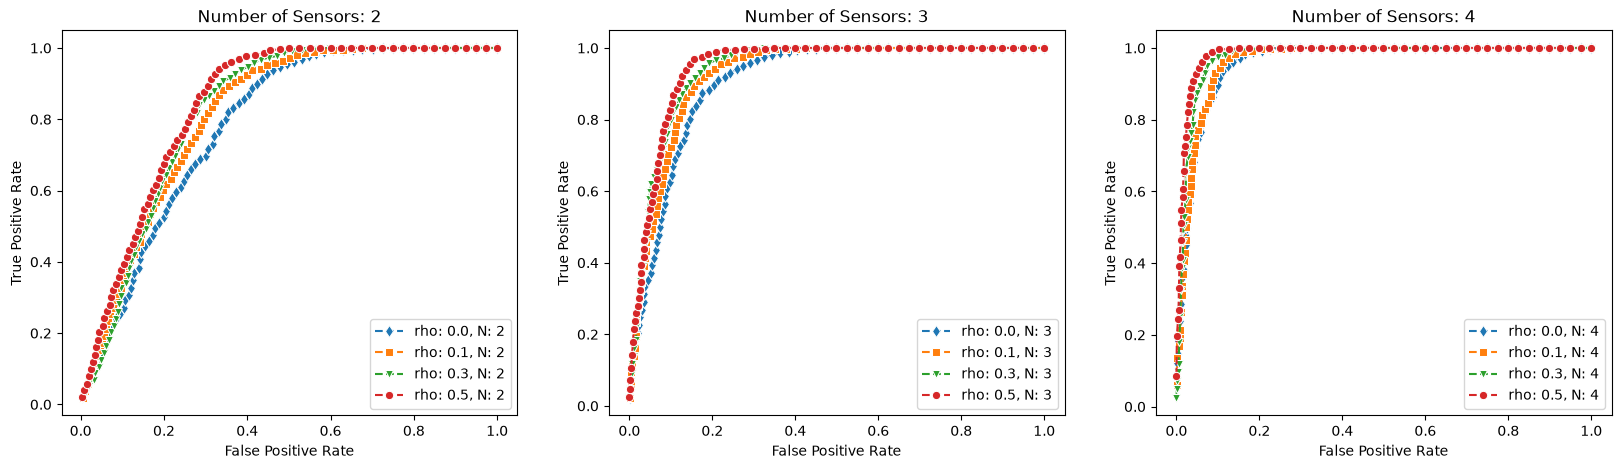

In [96]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(20,5))

N = (2, 3, 4)
rho = (0.0, .1, .3, .5)
markers = ['d', 's', 'v', 'o']

for r, m in zip(rho, markers):
    for p, n in enumerate(N):

        # ------------ 1. For each object, generate one track per sensors -----------
        # We do this by generating the correlated errors and adding them to the true state
        # of the objects of interest, as shown by equation 45/46 in the appendix. 
        # ----------------------------------------------------------------------------
        
        # error shape (n_states, n_objects, n_sensors)
        err_cov = np.full((n, n), r)
        np.fill_diagonal(err_cov, 1.0)
        err = np.random.multivariate_normal(np.zeros(n), err_cov, size=1000).T

        # err + true_states --> (n_sensors, n_objects) + (n_objects) = (n_sensors, n_objects)
        tracks = err + true_states[None, :]

        # --------------------------------------------------------------------------
        # ----------- 2. Form candidate track associations -------------------------
        # NOTE: the track tensor can be used for valid associations. For example track[:, j] 
        #       gives all measurements associated with object j. So, we only need to form the 
        #       invalid associations. 
        # --------------------------------------------------------------------------
        
        # form 1000 S-Tuples of invalid associations
        invalid_associations = np.empty_like(tracks)
        for i in range(n):
            invalid_associations[i] = np.roll(tracks[i], i)

        # --------------------------------------------------------------------------
        # --------- 3. Grade all associations with negative log likelihood ---------
        # --------------------------------------------------------------------------

        # form covariance matrix for measurement likelihood, described in eqns 13 and 14
        # ... vastly simplified by the assumption of scalar states and constant rho
        P = np.full((n - 1, n - 1), 1 - r)
        np.fill_diagonal(P, 2 * (1 - r))
        mvn = multivariate_normal(mean=np.zeros(n - 1), cov=P)

        # these are the likelihood function input vectors according to equation 12
        valid_diff = tracks[1:] - tracks[0] # (n_sensors - 1, n_objects)
        invalid_diff = invalid_associations[1:] - invalid_associations[0]

        valid_scores = mvn.pdf(valid_diff.T)
        invalid_scores = mvn.pdf(invalid_diff.T)

        scores = np.sort(np.concat([valid_scores, invalid_scores]))
        taus = np.linspace(scores.min(), scores.max(), num=50)
        
        tprs = []
        fprs = []
        
        for t in scores[::25]:
            tprs.append((valid_scores > t).sum() / 1000)
            fprs.append((invalid_scores > t).sum() / 1000)

        sns.lineplot(x=fprs, y=tprs, linestyle="--", marker=m, label=f"rho: {r}, N: {n}", ax=ax[p])

for i, a in enumerate(ax):
    a.set_title(f"Number of Sensors: {N[i]}")
    a.set_xlabel("False Positive Rate")
    a.set_ylabel("True Positive Rate")

plt.legend()
plt.show()